# 10 Rag Evaluation Platform

**Project:** LLMOps Monitoring & Evaluation Platform

**Notebook:** `10-rag-evaluation-platform.ipynb`

In [4]:
# Start coding here
print("Hello")

Hello


In [5]:
# ==========================================
# Notebook 10
# RAG Evaluation Platform
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [6]:
faithfulness_df = pd.read_csv("../evaluation_results/faithfulness_results.csv")

relevancy_df = pd.read_csv("../evaluation_results/answer_relevancy_results.csv")

context_df = pd.read_csv("../evaluation_results/context_recall_results.csv")

judge_df = pd.read_csv("../evaluation_results/llm_judge_results.csv")

In [7]:
print(len(faithfulness_df))
print(len(relevancy_df))
print(len(context_df))
print(len(judge_df))

20
20
20
20


In [8]:
rag_eval_df = pd.DataFrame(
    {
        "question": faithfulness_df["question"],
        "faithfulness": faithfulness_df["faithfulness"],
        "answer_relevancy": relevancy_df["answer_relevancy"],
        "context_recall": context_df["context_recall"],
        "judge_score": judge_df["weighted_score"],
    }
)

In [9]:
rag_eval_df.head()

,question,faithfulness,answer_relevancy,context_recall,judge_score
0,What is AWS?,1.0,0.771484,0.946617,0.0
1,What is Azure?,1.0,0.859219,0.983912,0.0
2,What is Google Cloud?,1.0,0.773407,1.000000,0.0
3,What is AWS?,1.0,0.700566,0.961204,0.0
4,What is Azure?,1.0,0.773966,0.975546,0.0


In [10]:
rag_eval_df["judge_score"] = rag_eval_df["judge_score"] / 10

In [11]:
rag_eval_df.head()

,question,faithfulness,answer_relevancy,context_recall,judge_score
0,What is AWS?,1.0,0.771484,0.946617,0.0
1,What is Azure?,1.0,0.859219,0.983912,0.0
2,What is Google Cloud?,1.0,0.773407,1.000000,0.0
3,What is AWS?,1.0,0.700566,0.961204,0.0
4,What is Azure?,1.0,0.773966,0.975546,0.0


In [12]:
def calculate_rag_health_score(row):

    score = (
        0.35 * row["faithfulness"]
        + 0.25 * row["answer_relevancy"]
        + 0.20 * row["context_recall"]
        + 0.20 * row["judge_score"]
    )

    return round(score, 4)

In [13]:
rag_eval_df["rag_health_score"] = rag_eval_df.apply(calculate_rag_health_score, axis=1)

In [14]:
rag_eval_df.head()

,question,faithfulness,answer_relevancy,context_recall,judge_score,rag_health_score
0,What is AWS?,1.0,0.771484,0.946617,0.0,0.7322
1,What is Azure?,1.0,0.859219,0.983912,0.0,0.7616
2,What is Google Cloud?,1.0,0.773407,1.000000,0.0,0.7434
3,What is AWS?,1.0,0.700566,0.961204,0.0,0.7174
4,What is Azure?,1.0,0.773966,0.975546,0.0,0.7386


In [15]:
def rag_health_label(score):

    if score >= 0.90:
        return "Excellent"

    elif score >= 0.80:
        return "Good"

    elif score >= 0.70:
        return "Average"

    return "Poor"

In [16]:
rag_eval_df["rag_health_label"] = rag_eval_df["rag_health_score"].apply(
    rag_health_label
)

In [17]:
rag_eval_df[["question", "rag_health_score", "rag_health_label"]]

,question,rag_health_score,rag_health_label
0,What is AWS?,0.7322,Average
1,What is Azure?,0.7616,Average
2,What is Google Cloud?,0.7434,Average
3,What is AWS?,0.7174,Average
4,What is Azure?,0.7386,Average
5,What is Google Cloud?,0.7474,Average
6,What is Oracle Cloud?,0.7572,Average
7,What is IBM Cloud?,0.7616,Average
8,Question 8,0.1341,Poor
9,Question 9,0.1299,Poor


In [18]:
rag_eval_df.describe()

,faithfulness,answer_relevancy,context_recall,judge_score,rag_health_score
count,20.000000,20.000000,20.000000,20.0,20.000000
mean,0.400000,0.414706,0.692841,0.0,0.382255
std,0.502625,0.325606,0.236019,0.0,0.304021
min,0.000000,0.115511,0.505165,0.0,0.129900
25%,0.000000,0.150827,0.505165,0.0,0.138725
50%,0.000000,0.193662,0.505165,0.0,0.149450
75%,1.000000,0.773547,0.973201,0.0,0.739800
max,1.000000,0.862217,1.000000,0.0,0.761600


In [19]:
def generate_rag_report(df):

    report = {
        "records": len(df),
        "avg_faithfulness": round(df["faithfulness"].mean(), 4),
        "avg_relevancy": round(df["answer_relevancy"].mean(), 4),
        "avg_context_recall": round(df["context_recall"].mean(), 4),
        "avg_judge_score": round(df["judge_score"].mean(), 4),
        "avg_rag_health": round(df["rag_health_score"].mean(), 4),
    }

    return report

In [20]:
generate_rag_report(rag_eval_df)

{'records': 20,
 'avg_faithfulness': 0.4,
 'avg_relevancy': 0.4147,
 'avg_context_recall': 0.6928,
 'avg_judge_score': 0.0,
 'avg_rag_health': 0.3823}

In [21]:
hallucinations = rag_eval_df[rag_eval_df["faithfulness"] < 0.70]

In [ ]:
hallucinations

,question,faithfulness,answer_relevancy,context_recall,judge_score,rag_health_score,rag_health_label
8,Question 8,0.0,0.132426,0.505165,0.0,0.1341,Poor
9,Question 9,0.0,0.115511,0.505165,0.0,0.1299,Poor
10,Question 10,0.0,0.122226,0.505165,0.0,0.1316,Poor
11,Question 11,0.0,0.139133,0.505165,0.0,0.1358,Poor
12,Question 12,0.0,0.126529,0.505165,0.0,0.1327,Poor
13,Question 13,0.0,0.169237,0.505165,0.0,0.1433,Poor
14,Question 14,0.0,0.163706,0.505165,0.0,0.1420,Poor
15,Question 15,0.0,0.162117,0.505165,0.0,0.1416,Poor
16,Question 16,0.0,0.154724,0.505165,0.0,0.1397,Poor
17,Question 17,0.0,0.183739,0.505165,0.0,0.1470,Poor


In [23]:
retrieval_failures = rag_eval_df[rag_eval_df["context_recall"] < 0.70]

In [24]:
retrieval_failures

,question,faithfulness,answer_relevancy,context_recall,judge_score,rag_health_score,rag_health_label
8,Question 8,0.0,0.132426,0.505165,0.0,0.1341,Poor
9,Question 9,0.0,0.115511,0.505165,0.0,0.1299,Poor
10,Question 10,0.0,0.122226,0.505165,0.0,0.1316,Poor
11,Question 11,0.0,0.139133,0.505165,0.0,0.1358,Poor
12,Question 12,0.0,0.126529,0.505165,0.0,0.1327,Poor
13,Question 13,0.0,0.169237,0.505165,0.0,0.1433,Poor
14,Question 14,0.0,0.163706,0.505165,0.0,0.1420,Poor
15,Question 15,0.0,0.162117,0.505165,0.0,0.1416,Poor
16,Question 16,0.0,0.154724,0.505165,0.0,0.1397,Poor
17,Question 17,0.0,0.183739,0.505165,0.0,0.1470,Poor


In [25]:
off_topic = rag_eval_df[rag_eval_df["answer_relevancy"] < 0.70]

In [26]:
off_topic

,question,faithfulness,answer_relevancy,context_recall,judge_score,rag_health_score,rag_health_label
8,Question 8,0.0,0.132426,0.505165,0.0,0.1341,Poor
9,Question 9,0.0,0.115511,0.505165,0.0,0.1299,Poor
10,Question 10,0.0,0.122226,0.505165,0.0,0.1316,Poor
11,Question 11,0.0,0.139133,0.505165,0.0,0.1358,Poor
12,Question 12,0.0,0.126529,0.505165,0.0,0.1327,Poor
13,Question 13,0.0,0.169237,0.505165,0.0,0.1433,Poor
14,Question 14,0.0,0.163706,0.505165,0.0,0.1420,Poor
15,Question 15,0.0,0.162117,0.505165,0.0,0.1416,Poor
16,Question 16,0.0,0.154724,0.505165,0.0,0.1397,Poor
17,Question 17,0.0,0.183739,0.505165,0.0,0.1470,Poor


In [27]:
correlation = rag_eval_df[
    [
        "faithfulness",
        "answer_relevancy",
        "context_recall",
        "judge_score",
        "rag_health_score",
    ]
].corr()

In [28]:
correlation

,faithfulness,answer_relevancy,context_recall,judge_score,rag_health_score
faithfulness,1.000000,0.991561,0.999183,NaN,0.999311
answer_relevancy,0.991561,1.000000,0.992335,NaN,0.995625
context_recall,0.999183,0.992335,1.000000,NaN,0.999174
judge_score,NaN,NaN,NaN,NaN,NaN
rag_health_score,0.999311,0.995625,0.999174,NaN,1.000000


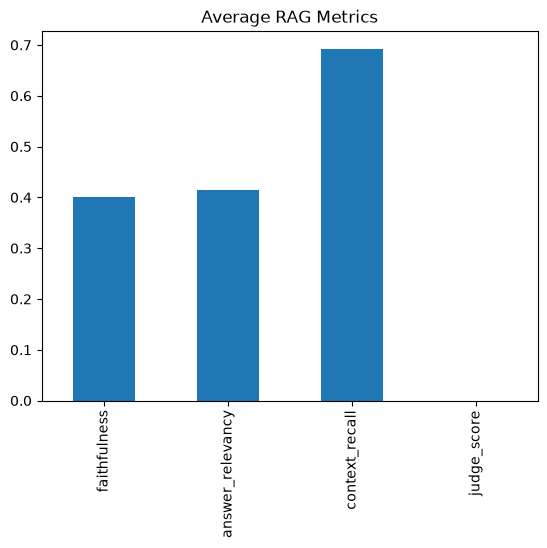

In [29]:
rag_eval_df[
    ["faithfulness", "answer_relevancy", "context_recall", "judge_score"]
].mean().plot(kind="bar")

plt.title("Average RAG Metrics")

plt.show()

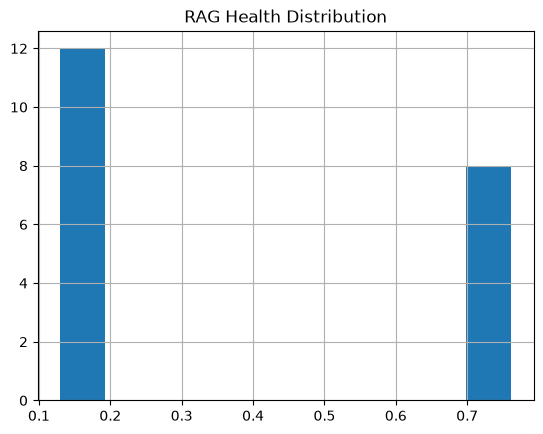

In [30]:
rag_eval_df["rag_health_score"].hist(bins=10)

plt.title("RAG Health Distribution")

plt.show()

In [31]:
rag_eval_df.sort_values(by="rag_health_score", ascending=False).head(10)

,question,faithfulness,answer_relevancy,context_recall,judge_score,rag_health_score,rag_health_label
1,What is Azure?,1.0,0.859219,0.983912,0.0,0.7616,Average
7,What is IBM Cloud?,1.0,0.862217,0.979998,0.0,0.7616,Average
6,What is Oracle Cloud?,1.0,0.848702,0.974948,0.0,0.7572,Average
5,What is Google Cloud?,1.0,0.811333,0.972618,0.0,0.7474,Average
2,What is Google Cloud?,1.0,0.773407,1.000000,0.0,0.7434,Average
4,What is Azure?,1.0,0.773966,0.975546,0.0,0.7386,Average
0,What is AWS?,1.0,0.771484,0.946617,0.0,0.7322,Average
3,What is AWS?,1.0,0.700566,0.961204,0.0,0.7174,Average
18,Question 18,0.0,0.220282,0.505165,0.0,0.1561,Poor
19,Question 19,0.0,0.203586,0.505165,0.0,0.1519,Poor


In [32]:
rag_eval_df.sort_values(by="rag_health_score", ascending=True).head(10)

,question,faithfulness,answer_relevancy,context_recall,judge_score,rag_health_score,rag_health_label
9,Question 9,0.0,0.115511,0.505165,0.0,0.1299,Poor
10,Question 10,0.0,0.122226,0.505165,0.0,0.1316,Poor
12,Question 12,0.0,0.126529,0.505165,0.0,0.1327,Poor
8,Question 8,0.0,0.132426,0.505165,0.0,0.1341,Poor
11,Question 11,0.0,0.139133,0.505165,0.0,0.1358,Poor
16,Question 16,0.0,0.154724,0.505165,0.0,0.1397,Poor
15,Question 15,0.0,0.162117,0.505165,0.0,0.1416,Poor
14,Question 14,0.0,0.163706,0.505165,0.0,0.1420,Poor
13,Question 13,0.0,0.169237,0.505165,0.0,0.1433,Poor
17,Question 17,0.0,0.183739,0.505165,0.0,0.1470,Poor


In [33]:
sample_result = {
    "trace_id": "trace_001",
    "faithfulness": 0.92,
    "answer_relevancy": 0.88,
    "context_recall": 0.91,
    "judge_score": 0.89,
    "rag_health_score": 0.90,
}

sample_result

{'trace_id': 'trace_001',
 'faithfulness': 0.92,
 'answer_relevancy': 0.88,
 'context_recall': 0.91,
 'judge_score': 0.89,
 'rag_health_score': 0.9}

In [34]:
rag_eval_df.to_csv("../evaluation_results/final_rag_evaluation.csv", index=False)

In [36]:
report_df = pd.DataFrame([generate_rag_report(rag_eval_df)])

report_df.to_csv("../reports/rag_platform_report.csv", index=False)